# Curvas de Aprendizaje: Laboratorio Didáctico de Sobreajuste (Overfitting)

### Propósito del cuaderno
Este cuaderno es un **laboratorio experimental aislado**. No utiliza las transacciones del proyecto; en su lugar, genera datos sintéticos con ruido controlado para demostrar de forma visual e intuitiva la diferencia matemática entre un modelo que **memoriza** y un modelo que **aprende**.

### La paradoja del estudiante:
* **Modelo memorión (Overfitting):** Se aprende de memoria las respuestas de los exámenes viejos (100% de nota en casa), pero cuando le toman un examen con preguntas nuevas, reprueba estrepitosamente.
* **Modelo que generaliza:** Entiende los conceptos de fondo; puede cometer algún error menor en la práctica, pero aprueba con solidez cualquier examen nuevo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.multioutput import MultiOutputRegressor, RegressorChain
from sklearn.model_selection import learning_curve

import warnings
warnings.filterwarnings('ignore')

## 1. Generación de datos sintéticos con ruido (`make_regression`)

### ¿Qué buscamos?
Crear un dataset artificial de 2,000 filas con 20 variables y 3 objetivos simultáneos (*Multi-output*), inyectando un nivel de dispersión (*noise=15.0*) para simular la imperfección del mundo real.

In [2]:
# 2000 datos de prueba con 3 resultados a predecir
X, y = make_regression(n_samples=2000, n_features=20, n_targets=3, noise=15.0, random_state=42)

print(f"Dimensiones de X (Características): {X.shape}")
print(f"Dimensiones de y (Targets Multioutput): {y.shape}")
print("Primeros 3 registros de y:\n", y[:3])

Dimensiones de X (Características): (2000, 20)
Dimensiones de y (Targets Multioutput): (2000, 3)
Primeros 3 registros de y:
 [[-206.87187378 -143.03039643   43.26161864]
 [-115.12399824  110.37465437   21.59400155]
 [ 116.761097    -33.71914353  -20.2377213 ]]


## 2. Herramienta de diagnóstico: Curvas de aprendizaje (`learning_curve`)

### ¿Cómo se interpreta el gráfico?
* **Eje X (Filas):** Cantidad de datos de entrenamiento suministrados (del 10% al 100%).
* **Eje Y (R² Score):** Coeficiente de determinación (1.0 = predicción perfecta, 0.0 = tan malo como predecir el promedio).
* **Línea Roja (Train):** Rendimiento del modelo sobre los mismos datos con los que estudió.
* **Línea Verde (Validación Cruzada):** Rendimiento del modelo sobre datos nuevos que nunca vio durante esa iteración.

In [3]:
def plot_learning_curve(estimator, title, X, y, cv=5):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Ejemplos de Entrenamiento (Filas)")
    plt.ylabel("Puntuación (R² Score)")

    # Proporciones de datos a usar (del 10% al 100%)
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    # Entrenamos y evaluamos
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='r2'
    )
    
    # Calculamos promedios
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid(True)
    
    # Dibujamos las franjas de color
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Graficar líneas
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score en Entrenamiento")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Score en Prueba (Validación Cruzada)")
    
    plt.legend(loc="best")
    plt.show()

## 3. Experimento 1: El desastre a propósito (Árbol sin restricciones)

### ¿Qué hace el código?
Entrena un `DecisionTreeRegressor(max_depth=None)`. Al no tener límite de profundidad, el árbol genera ramas infinitas hasta aislar cada punto de ruido.

### Señales de alarma (Red Flags visuales):
* **Línea Roja en 1.0 (100%):** Espejismo de perfección en entrenamiento.
* **Línea Verde estancada en ~0.20:** Desempeño pésimo en datos reales.
* **Brecha abismal (Gap):** Diagnóstico inequívoco de **Sobreajuste severo (Overfitting)**.

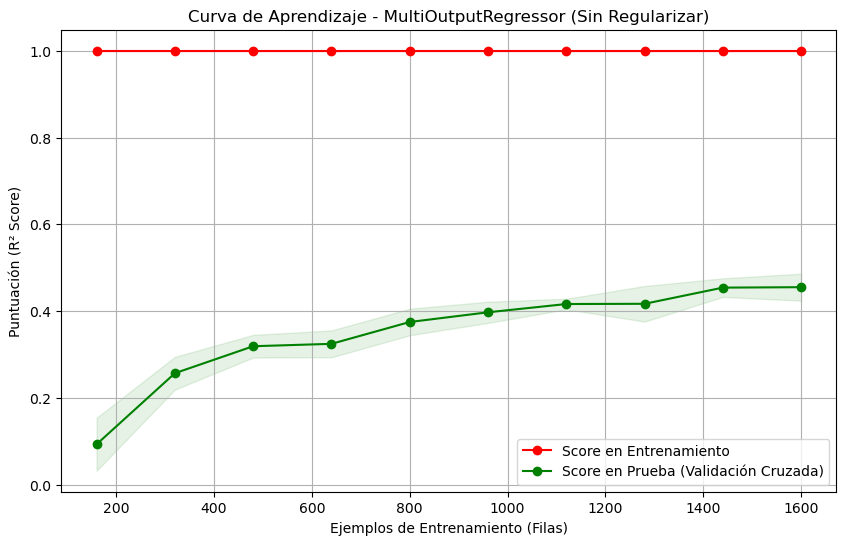

In [4]:
# Modelo sin límites (solo memoriza, no aprende)
base_tree = DecisionTreeRegressor(max_depth=None, random_state=42)
multi_model_overfit = MultiOutputRegressor(base_tree)

plot_learning_curve(
    multi_model_overfit, 
    "Curva de Aprendizaje - MultiOutputRegressor (Sin Regularizar)", 
    X, y
)

## 4. Experimento 2: El modelo podado (Poda y generalización)

### ¿Qué hace el código?
Entrena un `DecisionTreeRegressor(max_depth=5, min_samples_leaf=10)`. Le ponemos frenos regulatorios para impedir que memorice casos aislados.

### Señales de aprobación (Green Flags visuales):
* **Convergencia:** La línea roja baja un poco (~0.70) y la línea verde sube notablemente (~0.60).
* **Brecha estrecha:** La cercanía entre ambas curvas confirma que el modelo está aprendiendo patrones genuinos y no ruido.

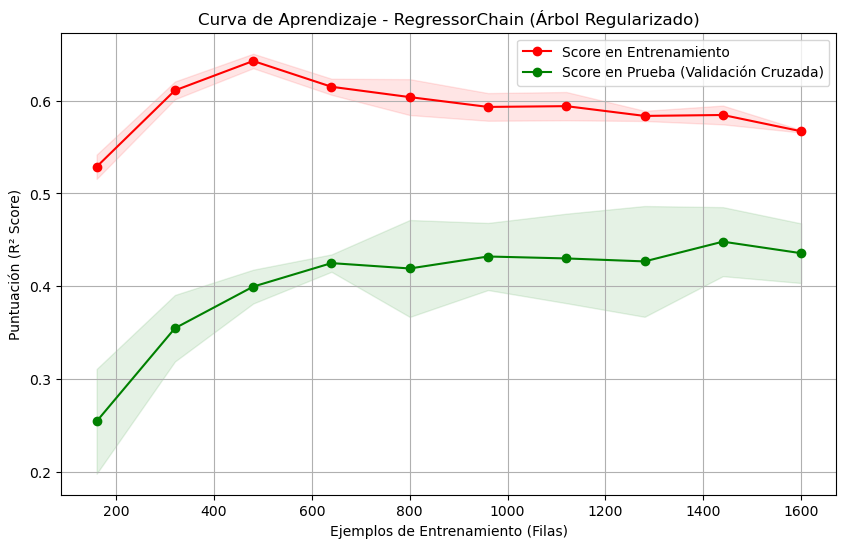

In [5]:
# Modelo con límites (piensa y aprende de verdad)
regularized_tree = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42)
chain_model = RegressorChain(regularized_tree)

plot_learning_curve(
    chain_model, 
    "Curva de Aprendizaje - RegressorChain (Árbol Regularizado)", 
    X, y
)

## 💡 Conclusión
Una curva de aprendizaje saludable muestra cómo el modelo mejora poco a poco. ¡Desconfía si un modelo saca puntaje perfecto desde el primer segundo en datos caóticos!

**¿Por qué nuestro Perfilador real sacó 100% y no está mal?**
En este laboratorio había mucho 'ruido' al azar, por lo que el 100% era trampa. Pero en nuestro proyecto real, los perfiles se asignaron con leyes matemáticas estrictas (ej. deuda > 26% = En riesgo). Nuestro modelo real sacó 100% simplemente porque descubrió esa ley matemática impecable, no porque haya memorizado trampa.